# Mining: Clustering Cryptocurrencies

Load processed features, aggregate by coin, scale, cluster with KMeans, and visualize with PCA.

Aggregated features shape: (23, 5)
               coin  log_return    vol_7d        Volume     Marketcap
0         coin_Aave    0.007368  0.078089  5.060201e+08  3.191265e+09
1  coin_BinanceCoin    0.005555  0.057279  6.278508e+08  7.846443e+09
2      coin_Bitcoin    0.001842  0.034705  1.091363e+10  1.209559e+11
3      coin_Cardano    0.003077  0.060574  8.946663e+08  7.613686e+09
4    coin_ChainLink    0.003538  0.068467  6.933595e+08  2.498169e+09
PCA explained variance ratio: [0.53532532 0.28249727]


c:\Users\admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


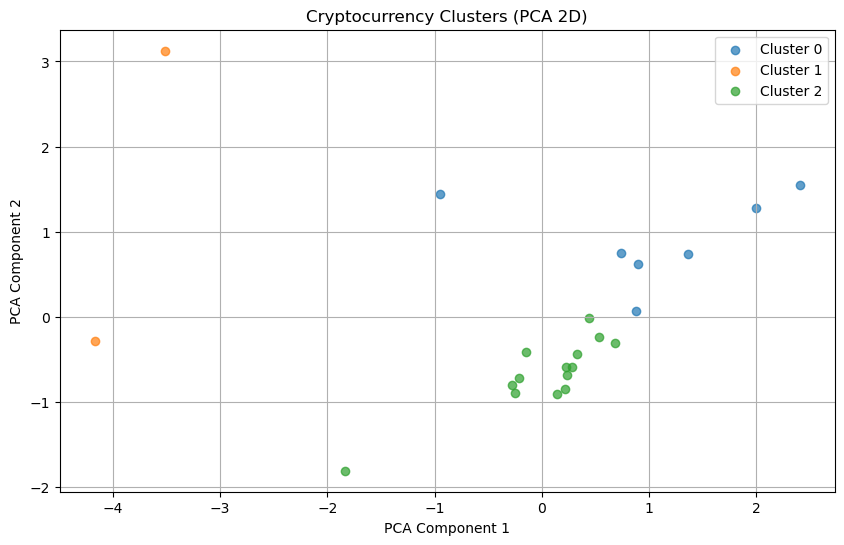

Cluster sizes:
cluster
2    14
0     7
1     2
Name: count, dtype: int64
\nCluster assignments:
                   coin  cluster
0             coin_Aave        0
1      coin_BinanceCoin        0
4        coin_ChainLink        0
9         coin_Ethereum        0
15          coin_Solana        0
14        coin_Polkadot        0
20         coin_Uniswap        0
2          coin_Bitcoin        1
17          coin_Tether        1
6    coin_CryptocomCoin        2
7         coin_Dogecoin        2
8              coin_EOS        2
11        coin_Litecoin        2
10            coin_Iota        2
5           coin_Cosmos        2
3          coin_Cardano        2
12          coin_Monero        2
13             coin_NEM        2
18            coin_Tron        2
16         coin_Stellar        2
19         coin_USDCoin        2
21  coin_WrappedBitcoin        2
22             coin_XRP        2


In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ensure the notebook runs from the project root
project_root = Path(r"D:/BTLDATA/DATA_MINING_PROJECT")
os.chdir(project_root)

# Load processed features
df = pd.read_parquet("data/processed/crypto_features.parquet")

# Drop any remaining NaNs (safety check)
df.dropna(inplace=True)

# Aggregate features by coin: mean return, volatility, volume, marketcap
agg_features = df.groupby("coin").agg({
    "log_return": "mean",
    "vol_7d": "mean",
    "Volume": "mean",
    "Marketcap": "mean",
}).reset_index()

print("Aggregated features shape:", agg_features.shape)
print(agg_features.head())

# Features for clustering
features = ["log_return", "vol_7d", "Volume", "Marketcap"]
X = agg_features[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method: evaluate inertia for k=2..10
inertia = []
ks = list(range(2, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertia, marker="o")
plt.title("KMeans Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(ks)
plt.grid(True)
plt.show()

# Perform KMeans clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
agg_features["cluster"] = clusters

# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
for cluster in np.unique(clusters):
    mask = clusters == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster}", alpha=0.7)

plt.title("Cryptocurrency Clusters (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# Display cluster assignments and sizes
print("Cluster sizes:")
print(agg_features["cluster"].value_counts())
print("\\nCluster assignments:")
print(agg_features[["coin", "cluster"]].sort_values("cluster"))